# Understanding the Governed Data World Pt1

Before proceeding with any analysis, we need to first understand what datasets we are dealing with. And refering to `analysis\dev_full_offline_investigation\surface_atlas.md`, we can see 7 classes:

Surface classes
- `traffic`: canonical behavioural traffic eligible for platform ingestion
- `context`: join or enrichment surface used to understand traffic
- `truth`: offline outcome or supervisory surface
- `telemetry`: audit or operational evidence, not business traffic


Time-safety classes
- `rtdl_safe`: eligible as decision-time context if used correctly
- `offline_only`: batch, truth, or closure-dependent surface; never live-decision input
- `not_traffic`: should not be treated as business traffic even if event-like

But first, we will examine the data as it moves from Layer-1 to Layer-3 so as to get an understanding of it before we begin investigating the surface classes.

Here is the [Layer-Layer view of Data Engine](../../../../docs/design/data-engine/data-engine-segment-synthesis-flow.png)

![data-engine-layer-layer-view](../../../../docs/design/data-engine/data-engine-segment-synthesis-flow.png)


At a high level, the Data Engine moves from **world construction** to **activity realisation** to **behaviour, fraud, and truth**.

- **Layer 1 (`1A` to `3B`) builds the governed world.**
  - `1A` decides the merchant and outlet footprint: how many outlets exist and in which countries.
  - `1B` places those outlets into concrete geography.
  - `2A` assigns civil time zones and DST/legal-time behaviour.
  - `2B` builds the routing fabric that later traffic can use.
  - `3A` refines merchants across intra-country zones where needed.
  - `3B` adds the virtual/edge world for merchants that operate through network edges rather than physical sites.

- **Layer 2 (`5A`, `5B`) brings that world to life over time.**
  - `5A` creates intensity shapes: when and how strongly activity should happen across merchants, classes, channels, zones, and scenarios.
  - `5B` turns those intensities into actual arrival skeletons, producing the first event-like activity surface, `arrival_events_5B`.

- **Layer 3 (`6A`, `6B`) turns arrivals into an entity-rich behavioural world with fraud and truth.**
  - `6A` builds the entity layer: parties, accounts, instruments, devices, IPs, and fraud-role posture.
  - `6B` attaches those entities to arrivals, generates behavioural event streams and flow anchors, overlays fraud campaigns, and then emits the truth products: event labels, flow truth, bank view, and case timelines.

The important interpretation is this: the engine first creates the **world**, then the **clock of activity**, then the **actors and behaviour**, and finally the **fraud/case truth** that the platform consumes offline or operationally. Also, `4A/4B` are not standalone production layers now; their concerns were folded in as cross-cutting gate, validation, and audit disciplines across the earlier segments. See [data_engine_interface.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/interface_pack/data_engine_interface.md), [narrative_1A-to-3B.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/layer-1/narrative/narrative_1A-to-3B.md), and [narrative_5A-and-5B.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/layer-2/narrative/narrative_5A-and-5B.md).


## Notebook Setup

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns

# Widen the notebook display so summary tables are easier to inspect while reading.
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)


In [2]:
# Walk upward from the current directory until we hit the repo root.
# We identify the root by the presence of AGENTS.md and the reference folder.
def find_repo_root(start: str | None = None) -> Path:
    here = Path(start or os.getcwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "reference").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root")


# Resolve the repo root once so every later path can be expressed relative to it.
ROOT = find_repo_root()
# Point to the exact merchant-universe parquet sealed into the current investigation basis.
transaction_schema_merchant_ids_path = ROOT / "reference" / "layer1" / "transaction_schema_merchant_ids" / "2026-01-03" / "transaction_schema_merchant_ids.parquet"
# Keep the associated bootstrap policy nearby because it is part of the sealed input story.
transaction_schema_bootstrap_policy_path = ROOT / "config" / "layer1" / "1A" / "ingress" / "transaction_schema_merchant_ids.bootstrap.yaml"

merchant_ids_df = pd.read_parquet(transaction_schema_merchant_ids_path)

# Echo the exact artefacts we are analysing so the notebook remains tied to the sealed run inputs.
print(f"transaction_schema_merchant_ids_path: {transaction_schema_merchant_ids_path}")
print(f"bootstrap_policy_path: {transaction_schema_bootstrap_policy_path}")
print(f"shape: {merchant_ids_df.shape}")


transaction_schema_merchant_ids_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\layer1\transaction_schema_merchant_ids\2026-01-03\transaction_schema_merchant_ids.parquet
bootstrap_policy_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\config\layer1\1A\ingress\transaction_schema_merchant_ids.bootstrap.yaml
shape: (10000, 4)


## Layer 1
[view-img](../../../../docs/design/data-engine/layer-1/layer-1-state-synthesis-flow.png)
![layer-1-view](../../../../docs/design/data-engine/layer-1/layer-1-state-synthesis-flow.png)

### Segment 1A

> "`1A` is the segment that turns a sealed merchant world into a certified outlet-world authority through deterministic lineage control, branch-gated stochastic realism, explicit cross-border order authority, deterministic country-weight and allocation bridges, fingerprint-scoped egress, and final replay validation."

1A Synthesis doc: [here](../../../../docs/design/data-engine/layer-1/1A/1A-state-synthesis.md)

![1A-overview-design-flow.png](../../../../docs/design/data-engine/layer-1/1A/1A-overview-design-flow.png)
[1A-overview-design-flow.png](../../../../docs/design/data-engine/layer-1/1A/1A-overview-design-flow.png)

#### Segment 1A.S0

![1A-S0-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S0-design-flow.png)
[1A-S0-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S0-design-flow.png)

1A.S0:
> "So `S0` is best understood as the lineage and precompute authority of `1A`, not just a preamble."

For `1A`, `S0` is not the whole segment. It does three things:
- seals the canonical external data universe
- opens and hashes the governed artefacts that define the lawful `1A` run
- emits the sealed `1A` input world and a small set of prep or diagnostic surfaces

A: **External data brought in at `S0.1`**
- `transaction_schema_merchant_ids`: ingress merchant universe
- `iso3166_canonical_2024`: canonical ISO country list
- `world_bank_gdp_per_capita_20250415`: pinned GDP-per-capita vintage
- `gdp_bucket_map_2024`: pinned GDP bucket map

B: **Governed artefacts opened at `S0.2`**
- `hurdle_coefficients.yaml`
- `nb_dispersion_coefficients.yaml`
- `crossborder_hyperparams.yaml`
- `ccy_smoothing_params.yaml`
- `s6_selection_policy.yaml`
- `policy.s3.rule_ladder.yaml`
- `policy.s3.base_weight.yaml` when enabled
- `policy.s3.thresholds.yaml` when referenced
- `transaction_schema_merchant_ids_bootstrap_policy`
- `settlement_shares_2024Q4`
- `ccy_country_shares_2024Q4`
- `numeric_policy_profile`
- `math_profile_manifest`
- optional `static.currency_to_country.map.json` when referenced by policy

C: **Datasets produced by `S0`**
- `sealed_inputs_1A`
- `s0_gate_receipt_1A`
- `crossborder_eligibility_flags`
- optional `crossborder_features`
- optional `hurdle_pi_probs`
- optionally materialised `hurdle_design_matrix`

What matters for the investigation at this stage is the distinction:
- `S0.1` tells us what external data world `1A` begins from
- `S0.2` tells us which governed model, policy, and numeric artefacts define the lawful run
- the `S0` outputs tell us what sealed world later `1A` states are allowed to consume


A.1: `transaction_schema_merchant_ids`
- version: `2026-01-03`
- path: `reference/layer1/transaction_schema_merchant_ids/2026-01-03/transaction_schema_merchant_ids.parquet`
- sha256: `df2f940f061a09a018e133828c9b7b2e7e442a1052b5c0105ef927e2b7c696e8`
- associated bootstrap policy: `config/layer1/1A/ingress/transaction_schema_merchant_ids.bootstrap.yaml`
- bootstrap policy sha256: `f99aace1899982bda221596b64fecd6ff240dd62d8be081159eb1c457765c6c7`

##### Initial analysis of `transaction_schema_merchant_ids`

We start with a bounded statistical summary of the merchant universe:
- shape
- schema
- nulls
- uniqueness
- distributions across `channel`, `home_country_iso`, and `mcc`


In [3]:
# Show a few rows first so we can see the raw row shape before computing summaries.
merchant_ids_df.head(10)

,merchant_id,mcc,channel,home_country_iso
0,1694081450446801,5561,card_present,LU
1,2697116941085629,4789,card_not_present,LU
2,3361754771680650,7996,card_present,ES
3,9012167658511518,4411,card_present,PF
4,10766668736889901,7631,card_present,JP
5,12629669232507242,8062,card_not_present,MC
6,14291053214586959,7699,card_not_present,FO
7,18638034984233531,4225,card_present,EC
8,19498508446557154,7534,card_present,IL
9,23202490577169710,7299,card_present,CA


In [4]:
merchant_ids_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   merchant_id       10000 non-null  uint64
 1   mcc               10000 non-null  int32 
 2   channel           10000 non-null  object
 3   home_country_iso  10000 non-null  object
dtypes: int32(1), object(2), uint64(1)
memory usage: 273.6+ KB


Build a compact column-level profile.

In [5]:
# This lets us see data types, null exposure, and cardinality in one table.
pd.DataFrame(
    {
        # Column names in their dataset order.
        "column": merchant_ids_df.columns,
        # Pandas dtypes tell us how the parquet landed in memory.
        "dtype": merchant_ids_df.dtypes.astype(str).values,
        # Absolute null counts highlight missingness immediately.
        "null_count": merchant_ids_df.isna().sum().values,
        # Null percentage makes the counts comparable across columns.
        "null_pct": (merchant_ids_df.isna().mean().mul(100).round(2)).values,
        # Distinct counts show the effective breadth of each field.
        "distinct_count": merchant_ids_df.nunique(dropna=False).values,
    }
)

,column,dtype,null_count,null_pct,distinct_count
0,merchant_id,uint64,0,0.0,10000
1,mcc,int32,0,0.0,290
2,channel,object,0,0.0,2
3,home_country_iso,object,0,0.0,190


Capture the first structural checks for the dataset.

In [6]:
# These tell us how big the merchant universe is and whether merchant_id behaves like a true key.
pd.DataFrame(
    [
        # Total row count in the merchant universe.
        {"check": "row_count", "value": len(merchant_ids_df)},
        # Distinct merchant IDs should match row count if merchant_id is unique.
        {"check": "merchant_id_distinct", "value": merchant_ids_df["merchant_id"].nunique()},
        # Duplicate merchant IDs would be an immediate structural concern for this ingress table.
        {"check": "merchant_id_duplicate_rows", "value": int(merchant_ids_df["merchant_id"].duplicated().sum())},
        # Number of represented home countries.
        {"check": "country_distinct", "value": merchant_ids_df["home_country_iso"].nunique()},
        # Number of represented MCC categories.
        {"check": "mcc_distinct", "value": merchant_ids_df["mcc"].nunique()},
        # Number of channel values present in the dataset.
        {"check": "channel_distinct", "value": merchant_ids_df["channel"].nunique()},
    ]
)

,check,value
0,row_count,10000
1,merchant_id_distinct,10000
2,merchant_id_duplicate_rows,0
3,country_distinct,190
4,mcc_distinct,290
5,channel_distinct,2


In [7]:
# Count merchants by channel to see the overall CP vs CNP split.
merchant_ids_df["channel"].value_counts(dropna=False).rename_axis("channel").reset_index(name="merchant_count")

,channel,merchant_count
0,card_present,7473
1,card_not_present,2527


List the most represented home countries.

In [8]:
# We limit to the top 20 so the first read stays compact.
merchant_ids_df["home_country_iso"].value_counts(dropna=False).head(20).rename_axis("home_country_iso").reset_index(name="merchant_count")

,home_country_iso,merchant_count
0,MC,800
1,BM,436
2,LU,379
3,IE,337
4,GH,315
5,CH,304
6,NO,262
7,SG,238
8,AU,212
9,US,211


Measure how much of the full merchant universe is captured by the leading countries.

In [9]:
# Rank countries by merchant count so we can see how quickly the merchant universe concentrates.
country_concentration_df = merchant_ids_df["home_country_iso"].value_counts(dropna=False).rename_axis("home_country_iso").reset_index(name="merchant_count")

# Convert raw counts into percentage share of the full merchant universe.
country_concentration_df["merchant_share_pct"] = (country_concentration_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Cumulative share shows how much of the universe is covered as we move down the ranked list.
country_concentration_df["cumulative_share_pct"] = country_concentration_df["merchant_share_pct"].cumsum().round(2)

# Inspect the leading rows first, then read off top-5, top-10, top-20 style coverage from the cumulative column.
country_concentration_df.head(20)

,home_country_iso,merchant_count,merchant_share_pct,cumulative_share_pct
0,MC,800,8.00,8.00
1,BM,436,4.36,12.36
2,LU,379,3.79,16.15
3,IE,337,3.37,19.52
4,GH,315,3.15,22.67
5,CH,304,3.04,25.71
6,NO,262,2.62,28.33
7,SG,238,2.38,30.71
8,AU,212,2.12,32.83
9,US,211,2.11,34.94


Visualise country concentration with a Pareto chart so we can see both rank order and cumulative coverage together.

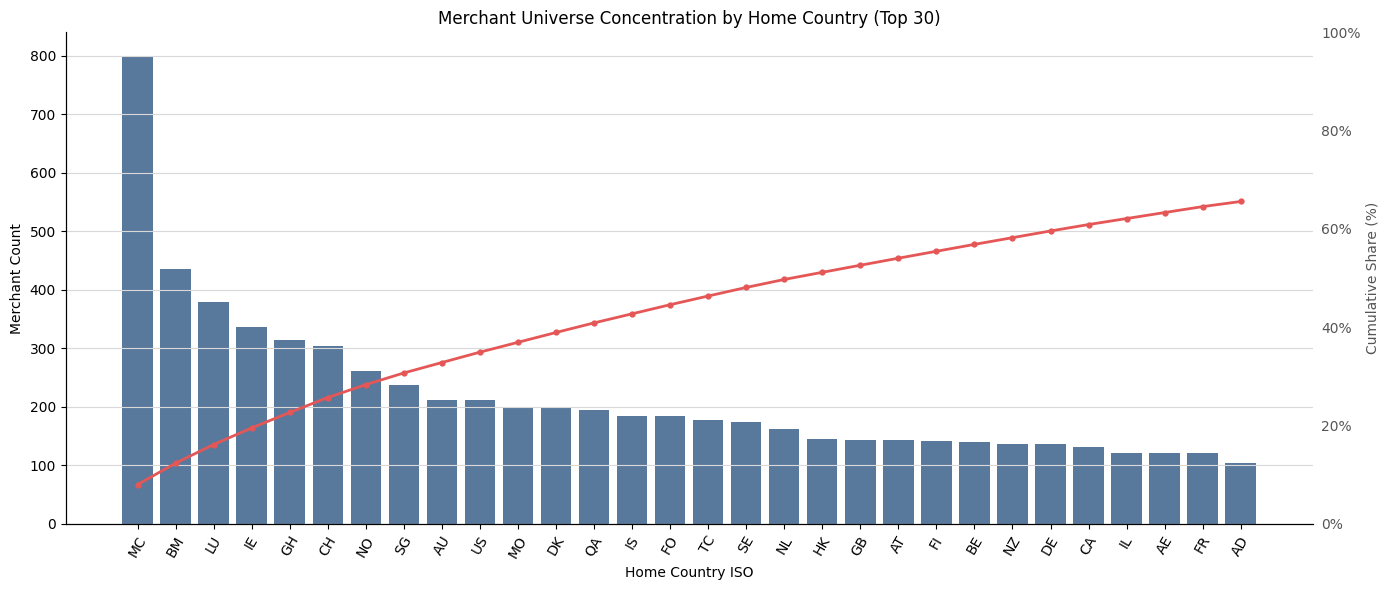

In [10]:
# Focus the chart on the top 30 countries so the x-axis stays readable.
country_plot_df = country_concentration_df.head(30).copy()

# Create the bar axis first because merchant count is the primary scale we want the eye to read.
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=country_plot_df, x="home_country_iso", y="merchant_count", color="#4C78A8", ax=ax1)
ax1.set_title("Merchant Universe Concentration by Home Country (Top 30)")
ax1.set_xlabel("Home Country ISO")
ax1.set_ylabel("Merchant Count")
ax1.tick_params(axis="x", rotation=60)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax1.grid(axis="x", visible=False)

# Add the cumulative-share line on a secondary axis, but keep that axis visually subordinate.
ax2 = ax1.twinx()
ax2.plot(
    range(len(country_plot_df)),
    country_plot_df["cumulative_share_pct"],
    color="#E45756",
    marker="o",
    markersize=3.5,
    linewidth=2,
)
ax2.set_ylabel("Cumulative Share (%)", color="#555555")
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", colors="#555555", length=0, pad=6)
ax2.grid(False)

plt.tight_layout()
plt.show()


**Interpretation:** Country concentration is much sharper than the raw merchant-count table first suggests. The Pareto curve tells us that the merchant seed world is not spread evenly across home-country jurisdictions; a small leading set carries a disproportionate share of the universe.

**Metrics behind the plot:** `190` distinct countries are present, but the top `5` already account for `22.67%` of the merchant universe, the top `10` for `34.94%`, the top `20` for `52.62%`, and the top `30` for `65.59%`. The leading jurisdiction alone (`MC`) contributes `800` merchants, or `8.00%` of the full `10,000`-merchant seed.

We now have a cleaner explanation for why this happens. Most of the heavy-country shape is deliberate: the merchant universe is generated from a GDP-per-capita-heavy allocation policy with heavy-tail and regional boosts, so affluent and boosted markets such as `MC`, `BM`, `LU`, and `IE` are expected to rise toward the top. One visible outlier, `GH`, is different: it is materially amplified by the builder's residual-allocation step rather than by the intended policy shape alone.

That matters for the later fraud and platform story because country is going to act as a hidden weight in several downstream surfaces. Routing geography, legal-time posture, cross-border opportunity, and even campaign concentration can all inherit this early imbalance. So this is not just a descriptive country chart; it is an early explanation boundary for how much of the downstream world is policy-shaped versus builder-shaped.

**Validation note:** The top-country concentration is real, but it should not be treated as one undifferentiated phenomenon. The rich-country cluster is mostly a governed consequence of the merchant-allocation policy, while `GH` is a builder-side allocation artefact caused by the residual reconciliation logic.

That distinction matters because `MC`, `BM`, `LU`, `IE`, and `GH` together account for `2,267` merchants (`22.67%` of the seed world), but they do not all mean the same thing analytically. If we later observe heavy traffic, cases, or labels from those countries, we should remember that some of that weight is intentional policy shape and some of it is implementation side-effect.

The detailed reconstruction is in [transaction_schema_country_concentration_explanation.md](../../../../analysis/dev_full_offline_investigation/00_investigation/watson_workbench/notes/transaction_schema_country_concentration_explanation.md).

---


List the most represented MCC codes.

In [11]:
# This shows whether the merchant universe is broadly spread or heavily concentrated in a few categories.
merchant_ids_df["mcc"].value_counts(dropna=False).head(20).rename_axis("mcc").reset_index(name="merchant_count")

,mcc,merchant_count
0,8651,52
1,7922,52
2,5992,51
3,5193,50
4,5937,49
5,7299,49
6,7011,47
7,4812,47
8,5521,47
9,7801,47


Measure how much of the full merchant universe is captured by the leading MCC codes.

In [12]:
# Rank MCCs by merchant count so we can compare category concentration with country concentration.
mcc_concentration_df = merchant_ids_df["mcc"].value_counts(dropna=False).rename_axis("mcc").reset_index(name="merchant_count")

# Express each MCC's count as a share of the full merchant universe.
mcc_concentration_df["merchant_share_pct"] = (mcc_concentration_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Cumulative share shows how quickly the top MCCs accumulate coverage.
mcc_concentration_df["cumulative_share_pct"] = mcc_concentration_df["merchant_share_pct"].cumsum().round(2)

# Inspect the leading rows first, then read off top-5, top-10, top-20 style coverage from the cumulative column.
mcc_concentration_df.head(20)

,mcc,merchant_count,merchant_share_pct,cumulative_share_pct
0,8651,52,0.52,0.52
1,7922,52,0.52,1.04
2,5992,51,0.51,1.55
3,5193,50,0.50,2.05
4,5937,49,0.49,2.54
5,7299,49,0.49,3.03
6,7011,47,0.47,3.50
7,4812,47,0.47,3.97
8,5521,47,0.47,4.44
9,7801,47,0.47,4.91


Visualise MCC concentration with the same Pareto structure so we can compare category concentration against country concentration.

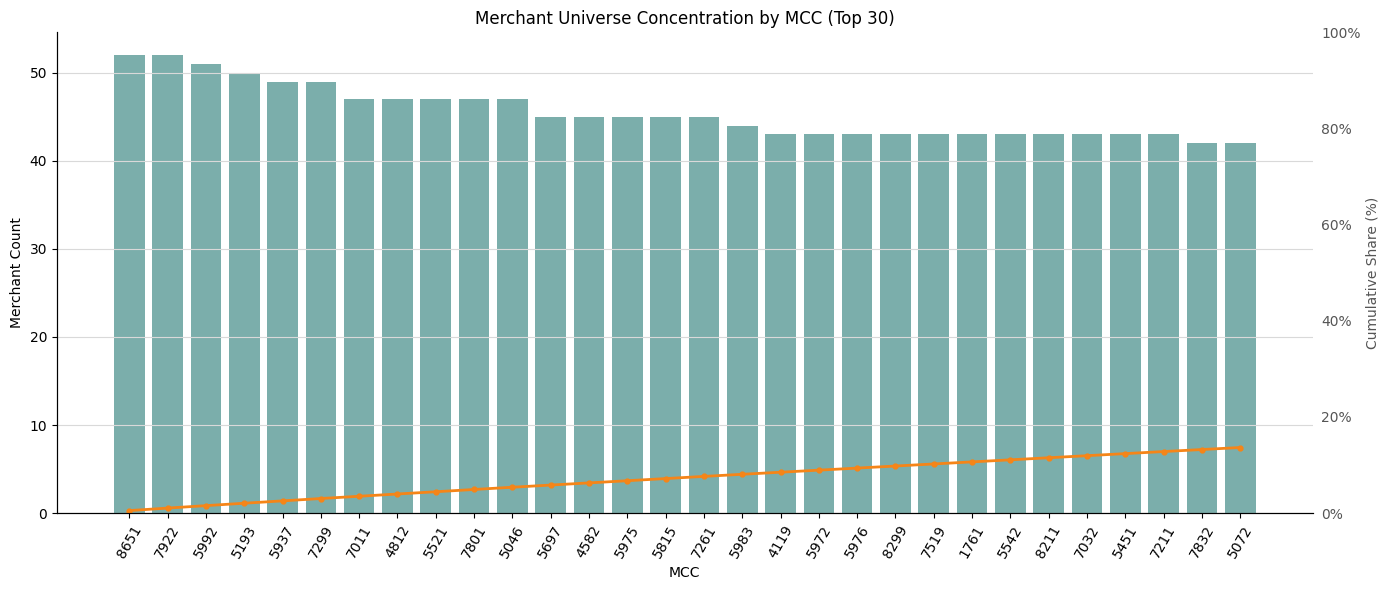

In [13]:
# Focus the chart on the top 30 MCC codes so the labels remain readable.
mcc_plot_df = mcc_concentration_df.head(30).copy()
mcc_plot_df["mcc"] = mcc_plot_df["mcc"].astype(str)

# Create the bar axis first because merchant count is still the primary quantity being displayed.
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=mcc_plot_df, x="mcc", y="merchant_count", color="#72B7B2", ax=ax1)
ax1.set_title("Merchant Universe Concentration by MCC (Top 30)")
ax1.set_xlabel("MCC")
ax1.set_ylabel("Merchant Count")
ax1.tick_params(axis="x", rotation=60)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax1.grid(axis="x", visible=False)

# Add the cumulative-share line on a secondary axis, but keep that axis visually subordinate.
ax2 = ax1.twinx()
ax2.plot(
    range(len(mcc_plot_df)),
    mcc_plot_df["cumulative_share_pct"],
    color="#F58518",
    marker="o",
    markersize=3.5,
    linewidth=2,
)
ax2.set_ylabel("Cumulative Share (%)", color="#555555")
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", colors="#555555", length=0, pad=6)
ax2.grid(False)

plt.tight_layout()
plt.show()


**Interpretation:** MCC concentration behaves very differently from country concentration. The slower cumulative rise means category exposure is distributed across many merchant classes rather than being dominated by a tiny commercial niche.

**Metrics behind the plot:** `290` distinct MCCs are represented. The top `10` MCCs cover only `4.91%` of merchants, the top `20` `9.36%`, the top `30` `13.64%`, and even the top `100` only `41.23%`. The leading MCC count is `52`, so no single category contributes even `1%` of the merchant universe.

That is a useful structural signal because it tells us the merchant world has two different shapes at once: jurisdiction is top-heavy, but merchant-category mix is broader. For downstream behaviour and fraud analysis, that is healthier than sharp MCC dominance would be, because later layers have room to vary by commercial type instead of inheriting a world overfit to a few categories.

So the important reading is not only that MCC is diffuse. It is that category diversity may partially offset the country skew, which will matter later when we ask whether suspicious pressure is concentrated because of geography, campaign design, or genuine commercial mix.

In [14]:
# First identify the countries with the largest merchant counts.
top_countries = merchant_ids_df["home_country_iso"].value_counts().head(15).index
# Then cross-tab those countries against channel to inspect country-level channel mix.
pd.crosstab(
    merchant_ids_df.loc[merchant_ids_df["home_country_iso"].isin(top_countries), "home_country_iso"],
    merchant_ids_df.loc[merchant_ids_df["home_country_iso"].isin(top_countries), "channel"],
).sort_index()

channel,card_not_present,card_present
home_country_iso,,
AU,53,159
BM,109,327
CH,76,228
DK,50,150
FO,46,139
GH,79,236
IE,84,253
IS,46,139
LU,95,284


Visualise the overall channel split so we can see the merchant seed universe's global CP vs CNP posture at a glance.

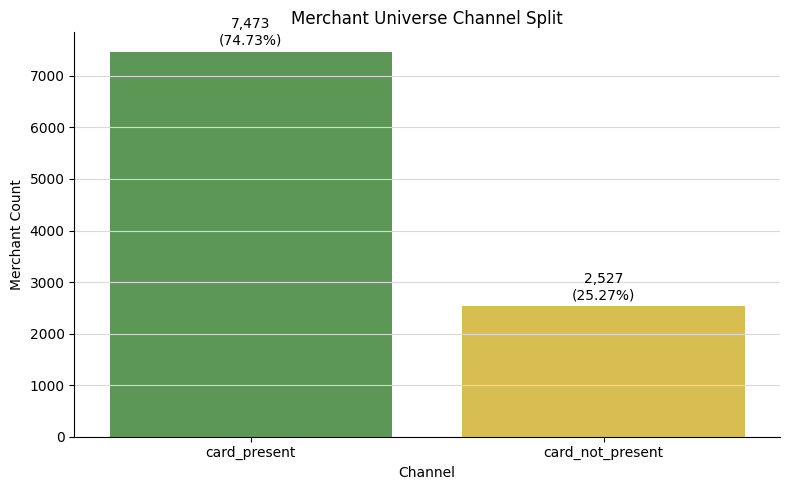

In [15]:
# Rebuild the channel summary with percentage labels so the bar chart can show both counts and share.
channel_plot_df = merchant_ids_df["channel"].value_counts(dropna=False).rename_axis("channel").reset_index(name="merchant_count")
channel_plot_df["merchant_share_pct"] = (channel_plot_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Plot the two channel categories directly because this is a simple composition check rather than a ranked concentration chart.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=channel_plot_df, x="channel", y="merchant_count", hue="channel", dodge=False, palette=["#54A24B", "#EECA3B"], ax=ax)
legend = ax.get_legend()
if legend is not None:
    legend.remove()

ax.set_title("Merchant Universe Channel Split")
ax.set_xlabel("Channel")
ax.set_ylabel("Merchant Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="x", visible=False)

# Write count and percentage above each bar so the chart is readable without referring back to the table.
for i, row in channel_plot_df.reset_index(drop=True).iterrows():
    ax.text(i, row["merchant_count"] + 80, f"{row['merchant_count']:,}\n({row['merchant_share_pct']:.2f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


**Interpretation:** The merchant seed universe is clearly channel-tilted toward `card_present`, not channel-balanced. The `~75 / 25` split tells us the baseline world is anchored in physical or in-person commerce, with `card_not_present` activity present but secondary.

**Metrics behind the plot:** `card_present` accounts for `7,473` merchants (`74.73%`) versus `2,527` `card_not_present` merchants (`25.27%`). With only `2` channel values in the seed universe, this is not noise in a long tail; it is the defining baseline composition.

That matters because channel posture is likely to influence later entity behaviour, device use, fraud opportunity, and case or label composition. A world that begins mostly `card_present` should not later be interpreted as if `card_not_present` pressure is the natural default. Any downstream CNP-heavy fraud or workflow pattern would therefore need to be explained as a campaign overlay, routing effect, or behavioural shift rather than as a neutral starting posture.

So the analytical takeaway is not just the ratio itself. It is the constraint the ratio places on later interpretation: channel comparisons downstream should be read against a deliberately tilted merchant seed, not against an assumption of equal baseline exposure.

#### Question

Once we know the merchant universe is country-concentrated, do the heavy countries actually behave differently from the rest of the seed world, or are they mostly enlarged versions of the same merchant universe?

**Why this matters?**

The country Pareto chart tells us where merchant weight sits, but not whether that weight implies specialised merchant composition, different channel behaviour, or a structural analytical risk. This follow-up checks the top-country mix directly.

**Top-country set**
- Investigated countries: `MC, BM, LU, IE, GH, CH, NO, SG, AU, US`
- These are the top 10 home countries by merchant count in the 10,000-row merchant universe.
